In [65]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from src.model import radius_model # load model functions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


In [30]:
df = pd.read_csv("../data/processed/bubble_curves.csv")
print(df)

        time_s  radius_um condition_id
0     0.000000  15.000000        f0_93
1    10.040053  11.977064        f0_93
2    14.098798   9.986239        f0_93
3    20.293725   7.931193        f0_93
4    27.556742   4.045872        f0_93
5     0.000000  15.000000           f1
6    10.360481  15.003440           f1
7    35.781041  14.802752           f1
8    55.754339  14.794725           f1
9    84.379172  14.802752           f1
10  106.381842  14.891055           f1
11  125.767690  15.099771           f1
12  145.847797  14.987385           f1
13    0.000000  15.000000        f0_84
14    5.340454  11.912844        f0_84
15   10.040053   6.967890        f0_84
16   12.016021   4.944954        f0_84
17   13.244326   2.440367        f0_84
18    0.000000  15.000000        f0_98
19   15.380507  13.951835        f0_98
20   62.002670  10.636468        f0_98
21   87.369826   8.725917        f0_98
22  114.018692   6.422018        f0_98
23  133.404539   5.017202        f0_98
24  148.090788   2.408257

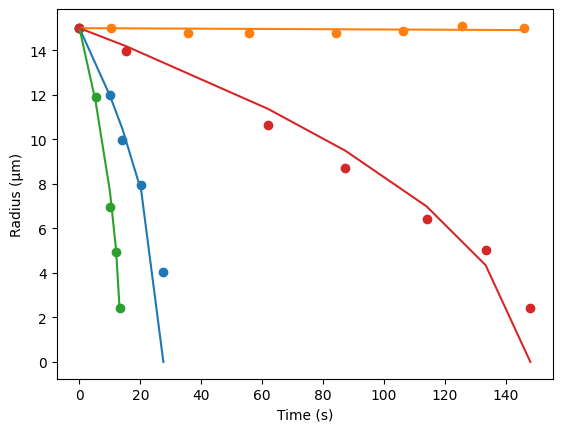

In [67]:
# Define the model function for curve fitting
# The initial radius R0 is known 
R0 = df['radius_um'][0]  
# Fit the first condition, make it work, then automate all conditions.
condition_names = df['condition_id'].unique()

df_results = pd.DataFrame(columns=['condition_id', 'R0_um', 'k_fit', 'RMSE'])
plt.figure()

for cond in df['condition_id'].unique():

    data = df[df['condition_id'] == cond]

    t = data['time_s'].values
    r = data['radius_um'].values

    k_guess = 0.01

    popt, _ = curve_fit(radius_model, t, r, p0=[k_guess])

    k_fit = popt[0]

    r_pred = radius_model(t, k_fit)

    rmse = np.sqrt(np.mean((r - r_pred)**2))

    df_results.loc[len(df_results)] = [cond, R0, k_fit, rmse]

    # compare fitted curve to data
    plt.scatter(t, r, label="data")
    plt.plot(t, r_pred, label="fit")

# plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Radius (µm)")
plt.show()

# save results
df_results.to_csv("../results/fitted_k_values.csv", index=False)


In [88]:
# Use bootstrap to estimate confidence intervals for k_fit 

# bootstrap may fail to converge for some resampled datasets, so catch warnings and errors to avoid crashing the loop
import warnings
from scipy.optimize import OptimizeWarning


bootstrap_results = pd.DataFrame(columns=['condition_id', 'k_mean', 'lower', 'upper'])
k_boot_results = [] # store bootstrap k values for each condition

for cond in condition_names:
    data = df[df["condition_id"] == cond]
    

    t = data["time_s"].values
    r = data["radius_um"].values

    n = len(data)
    # run bootstrap loop
    k_boot = [] # reset each time so values do not accumulate across conditions
    for i in range(500):

        idx = np.random.choice(n, size=n, replace=True)

        t_sample = t[idx]
        r_sample = r[idx]

        # with small datasets, it is common for SciPy to find a best-fit k, but not reliably estimate parameter uncertainty from that resampled subset
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", OptimizeWarning)

                popt, _ = curve_fit(
                    radius_model,
                    t_sample,
                    r_sample,
                    p0=[0.01],
                    maxfev=5000 # increase max function evaluations to help with convergence
                            )

            k_boot.append(popt[0])

        except:
            pass

    # Generate confidence intervals
    k_boot = np.array(k_boot)
    lower = np.percentile(k_boot, 2.5)
    upper = np.percentile(k_boot, 97.5)
    mean_k = np.mean(k_boot)
    bootstrap_results.loc[len(bootstrap_results)] = [cond, mean_k, lower, upper]
    k_boot_results.append(k_boot) # Bootstrap results for condition i are stored in k_boot_results[i], which is a list of fitted k values from each bootstrap iteration for that condition.

# # check how many bootstrap samples were successful
# print(len(k_boot))

print(bootstrap_results.sort_values(by='condition_id'))

  condition_id    k_mean     lower     upper
2        f0_84  8.431676  8.263262  8.787230
0        f0_93  4.082241  3.789442  4.442756
3        f0_98  0.823917  0.758020  0.908979
1           f1  0.011535 -0.002302  0.039315


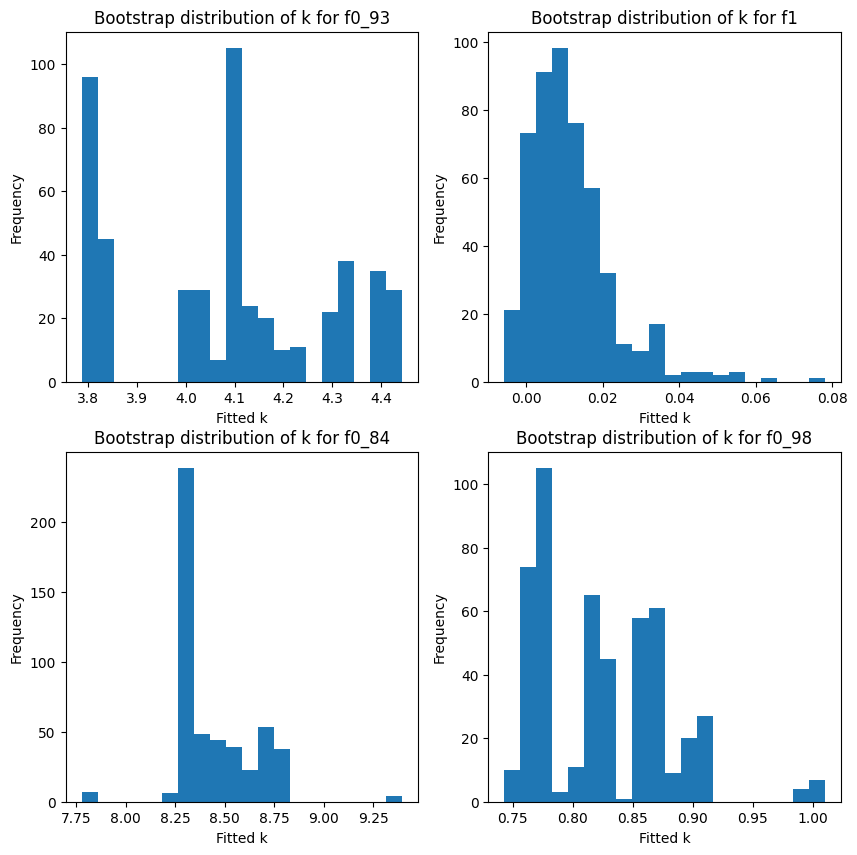

In [89]:
# Generate a histogram for each condition to demonstrate the bootstrap distribution of k
import matplotlib.pyplot as plt

# In this example, there are 4 conditions so plot as 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 10))


for i in range(len(condition_names)):
    ax = axs[i//2, i%2]
    k_boot = k_boot_results[i]
    ax.hist(k_boot, bins=20)
    ax.set_xlabel("Fitted k")
    ax.set_ylabel("Frequency")
    ax.set_title(f"Bootstrap distribution of k for {condition_names[i]}")
# plt.hist(k_boot, bins=20)
# plt.xlabel("Fitted k")
# plt.ylabel("Frequency")
# plt.title("Bootstrap distribution of k")
plt.show()

Now, we have fitted *k* distributions via bootstrap and have one corresponding histogram per condition. We now proceed to plot the effective dissolution rate *k* against gas saturation fraction *f*, with 95% confidence intervals. We expect that, for larger values of *f* corresponding to more saturation, the value of *k* will be smaller. 

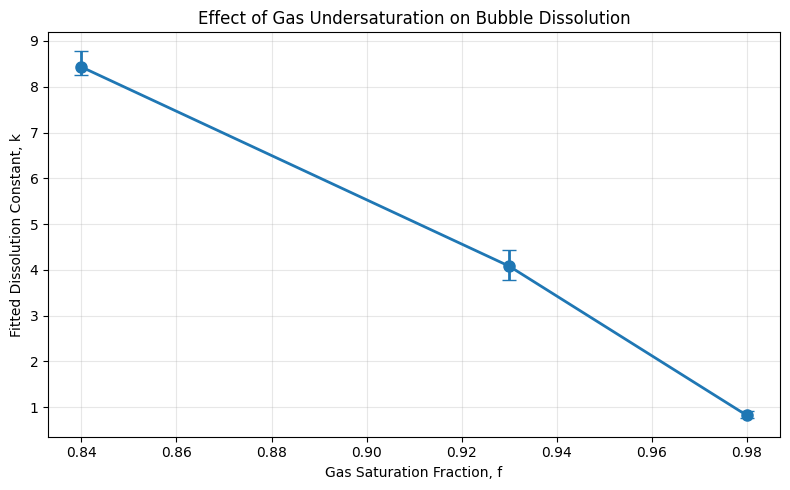

In [ ]:
f_map = {
    "f0_84": 0.84,
    "f0_93": 0.93,
    "f0_98": 0.98,
    "f1_00": 1.00
}

bootstrap_results["f"] = bootstrap_results["condition_id"].map(f_map)
bootstrap_results = bootstrap_results.sort_values("f")

# compute error bars for k
yerr_lower = bootstrap_results["k_mean"] - bootstrap_results["lower"]
yerr_upper = bootstrap_results["upper"] - bootstrap_results["k_mean"]

plt.figure(figsize=(8,5))

plt.errorbar(
    bootstrap_results["f"],
    bootstrap_results["k_mean"],
    yerr=[yerr_lower, yerr_upper],
    fmt="o-",
    capsize=5,
    linewidth=2,
    markersize=8
)

plt.xlabel("Gas Saturation Fraction, f")
plt.ylabel("Fitted Dissolution Constant, k")
plt.title("Effect of Gas Undersaturation on Bubble Dissolution")
plt.grid(True, alpha=0.3)
plt.tight_layout()

# save figure 
plt.savefig("../figures/k_vs_saturation.png", dpi=300, bbox_inches="tight")
plt.show()
